In [1]:
# ============================================================
# Lab7: IQP + StronglyEntanglingLayers Variational Quantum Regression
# ============================================================
# IQPEmbedding + StronglyEntanglingLayers 기반 Variational Quantum Regression.
# 두 입력 데이터(x1, x2)를 IQP feature map으로 인코딩하고
# StronglyEntanglingLayers ansatz를 이용해 표현력이 높은 양자 회귀 모델을 학습한다.
# 학습 과정은 실시간 그래프로 시각화되며 모델 수렴 과정과 예측 정확도를 확인한다.
# 실습 목표
#
# 1. IQPEmbedding을 이용한 데이터 인코딩 이해
# 2. StronglyEntanglingLayers를 이용한 expressive ansatz 이해
# 3. Variational Quantum Regression 학습 과정 관찰
# 4. 실시간 학습 시각화로 모델 수렴 과정 이해
# 5. Lab6의 RY+CNOT 모델과 표현력 차이 비교


# ============================================================
# 설치 (Colab용)
# ============================================================

# !pip install pennylane koreanize_matplotlib -q

In [2]:
# ============================================================
# 라이브러리
# ============================================================

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from IPython.display import clear_output

plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ============================================================
# ===== 수정 영역 =====
# ============================================================

n_layers = 3
epochs = 100
lr = 0.01

# 추천
# n_layers = 1 / 2 / 3
# lr = 0.001 / 0.01 / 0.1

In [4]:
# ============================================================
# Lab5 / Lab6 동일 데이터
# ============================================================

x1 = std_np.array([2*i + 1 for i in range(50)], dtype=float)
x2 = std_np.array([2*(i + 1) for i in range(50)], dtype=float)

y = x1 * x2

THEORY_SUM = 169150


def scale_x(x):
    return (x - 1) / 99 * std_np.pi


Y_MIN = 2.0
Y_MAX = 9900.0


def scale_y(y_val):
    return (y_val - Y_MIN) / (Y_MAX - Y_MIN)


def unscale_y(y_sc):
    return y_sc * (Y_MAX - Y_MIN) + Y_MIN


x1_sc = scale_x(x1)
x2_sc = scale_x(x2)
y_sc = scale_y(y)

In [5]:
# ============================================================
# train / test 분할
# ============================================================

std_np.random.seed(42)

idx = std_np.random.permutation(50)

n_train = 35

idx_train = idx[:n_train]
idx_test = idx[n_train:]

print(f"train: {n_train}개, test: {len(idx_test)}개")

train: 35개, test: 15개


In [6]:
# ============================================================
# Quantum Device
# ============================================================

dev = qml.device("default.qubit", wires=2)

In [7]:
# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(dev)
def vqr_iqp(inputs, weights):

    # IQP Encoding
    qml.IQPEmbedding(inputs, wires=[0,1], n_repeats=1)

    # Variational Ansatz
    qml.StronglyEntanglingLayers(weights, wires=[0,1])

    return qml.expval(qml.PauliZ(0))

In [8]:
# ============================================================
# 파라미터 구조
# ============================================================

w_shape = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers,
    n_wires=2
)

n_params = int(std_np.prod(w_shape))

print("\n회로 구조")

print(f"IQPEmbedding + StronglyEntanglingLayers x {n_layers}")

print(f"파라미터 형상: {w_shape}")
print(f"총 파라미터: {n_params}")


회로 구조
IQPEmbedding + StronglyEntanglingLayers x 3
파라미터 형상: (3, 2, 3)
총 파라미터: 18


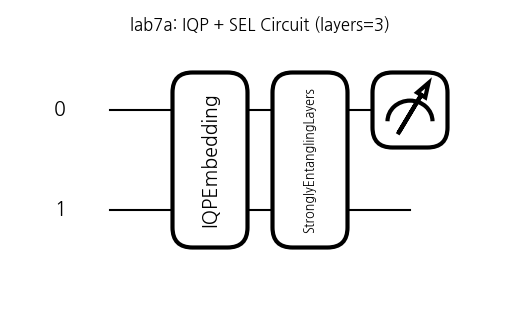

In [9]:
# ============================================================
# 회로 시각화
# ============================================================

std_np.random.seed(42)

w_init = np.array(
    std_np.random.uniform(0, std_np.pi, w_shape),
    requires_grad=True
)

sample_input = np.array([x1_sc[0], x2_sc[0]])

fig, _ = qml.draw_mpl(vqr_iqp, decimals=2)(
    sample_input,
    w_init
)

fig.suptitle(f"lab7a: IQP + SEL Circuit (layers={n_layers})")

plt.show()

In [10]:
# ============================================================
# 비용 함수
# ============================================================

def vqr_cost(weights):

    loss = 0

    for i in idx_train:

        inp = np.array([x1_sc[i], x2_sc[i]])

        pred = (vqr_iqp(inp, weights) + 1)/2

        loss += (pred - y_sc[i])**2

    return loss / n_train

In [11]:
# ============================================================
# 예측 함수
# ============================================================

def vqr_predict(weights):

    preds = []

    for i in range(50):

        inp = np.array([x1_sc[i], x2_sc[i]])

        p_sc = (float(vqr_iqp(inp, weights)) + 1)/2

        preds.append(unscale_y(p_sc))

    return std_np.array(preds)

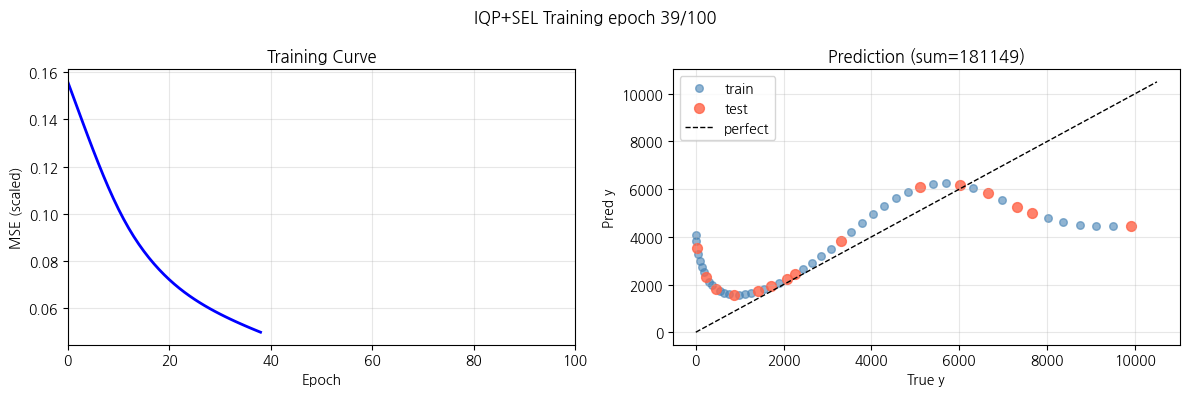

In [ ]:
# ============================================================
# 학습 (실시간 시각화 유지)
# ============================================================

opt = qml.AdamOptimizer(stepsize=lr)

weights = w_init.copy()

history = []


for ep in range(epochs):
    weights = opt.step(vqr_cost, weights)
    loss = float(vqr_cost(weights))
    history.append(loss)
    if ep % 2 == 0 or ep == epochs-1:
        clear_output(wait=True)
        preds_now = vqr_predict(weights)
        fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
        fig.suptitle( f"IQP+SEL Training epoch {ep+1}/{epochs}"   )
        # 학습곡선
        ax1.plot(history, 'b-', lw=2)
        ax1.set_xlabel("Epoch");        ax1.set_ylabel("MSE (scaled)")
        ax1.set_title("Training Curve"); ax1.set_xlim(0, epochs)
        ax1.grid(True, alpha=0.3)
        # 예측 vs 실제
        ax2.scatter(y[idx_train], preds_now[idx_train],c='steelblue', alpha=0.6,s=30,label='train')
        ax2.scatter(y[idx_test], preds_now[idx_test],c='tomato',alpha=0.8,s=50,label='test')
        ax2.plot( [0,10500],[0,10500],'k--',lw=1, label='perfect')
        ax2.set_xlabel("True y");        ax2.set_ylabel("Pred y")
        ax2.set_title( f"Prediction (sum={preds_now.sum():.0f})" )
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if ep == epochs-1:
            fig.savefig("./lab7_b.png", dpi=300)

        plt.show()

In [ ]:
# ============================================================
# 최종 결과
# ============================================================

vqr_preds = vqr_predict(weights)

vqr_sum = vqr_preds.sum()

vqr_test_mse = std_np.mean(
    (vqr_preds[idx_test] - y[idx_test])**2
)

print("\n결과")

print(f"IQP 총합: {vqr_sum:.1f} (이론 {THEORY_SUM})")

print(f"Test MSE: {vqr_test_mse:.2f}")

print(f"파라미터: {n_params} (shape={w_shape})")

print("\nlab7 완료!")

In [ ]:
# ============================================================
# 그래프 저장
# ============================================================

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(history, lw=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")

ax.set_title("lab7a: Training Curve")

ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig("./lab7_a.png", dpi=300)

plt.show()


fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(
    y[idx_train],
    vqr_preds[idx_train],
    alpha=0.6,
    s=30,
    label='train'
)

ax.scatter(
    y[idx_test],
    vqr_preds[idx_test],
    alpha=0.8,
    s=50,
    label='test'
)

ax.plot([0,10500],[0,10500],'k--')

ax.set_xlabel("True y")
ax.set_ylabel("Pred y")

ax.set_title(f"lab7a: Prediction vs True (sum={vqr_sum:.0f})")

ax.legend()

ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig("./lab7_b.png", dpi=300)

plt.show()